<a href="https://colab.research.google.com/github/WaskoSTUDY/Sztuczna-Inteligencja/blob/main/Laboratorium_nr_1_19769_Sztuczna_Inteligencja.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Laboratoria nr 1.


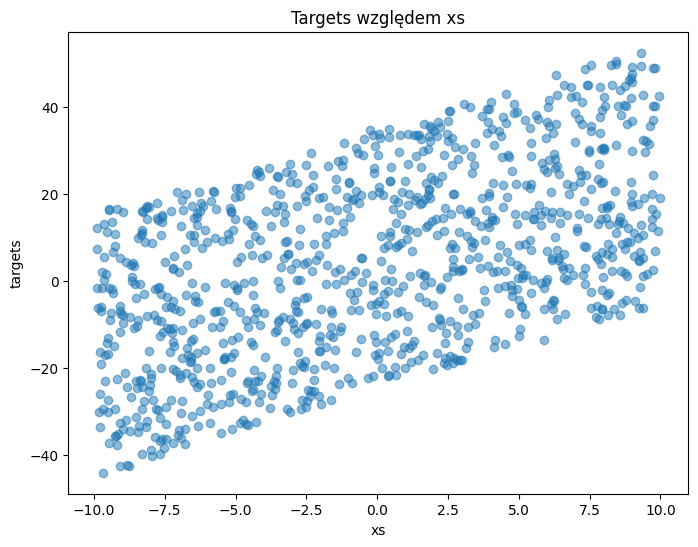

Początkowe wagi:
[[ 0.03291243]
 [-0.01179864]]
Początkowy bias:
[0.03757825]
Epoka 0, loss = 221.0811
Epoka 10, loss = 8.4782
Epoka 20, loss = 5.7202
Epoka 30, loss = 3.8776
Epoka 40, loss = 2.6466
Epoka 50, loss = 1.8242
Epoka 60, loss = 1.2747
Epoka 70, loss = 0.9076
Epoka 80, loss = 0.6623
Epoka 90, loss = 0.4985
Nauczone wagi:
[[ 1.9973736]
 [-2.9943967]]
Nauczony bias:
[4.340264]
Pierwsze 10 przewidywań modelu:
[[ 18.185196 ]
 [ 19.835798 ]
 [ -8.727119 ]
 [ -5.6260476]
 [-27.760239 ]
 [-18.911095 ]
 [-24.828224 ]
 [ -1.94453  ]
 [ 23.371418 ]
 [ 13.285553 ]]
Pierwsze 10 targetów:
tf.Tensor(
[[ 18.397041  ]
 [ 20.008472  ]
 [ -7.2844834 ]
 [ -5.4880614 ]
 [-27.609024  ]
 [-17.768425  ]
 [-24.31377   ]
 [ -0.75127214]
 [ 23.195251  ]
 [ 13.932548  ]], shape=(10, 1), dtype=float32)


In [24]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

np.random.seed(42)
tf.random.set_seed(42)

observations = 1000

xs = np.random.uniform(-10, 10, size=(observations, 1))
zs = np.random.uniform(-10, 10, size=(observations, 1))

inputs = np.column_stack((xs, zs))

noise = np.random.uniform(-1, 1, size=(observations, 1))

targets = 2 * xs - 3 * zs + 5 + noise

np.savez("TF_intro", inputs=inputs, targets=targets)


numpy_targets = targets
numpy_inputs = inputs
inputs = tf.constant(inputs, dtype=tf.float32)
targets = tf.constant(targets, dtype=tf.float32)

plt.figure(figsize=(8, 6))
plt.scatter(xs, numpy_targets, alpha=0.5)
plt.xlabel("xs")
plt.ylabel("targets")
plt.title("Targets względem xs")
plt.show()

weights = tf.Variable(tf.random.uniform(shape=(2, 1), minval=-0.1, maxval=0.1))
bias = tf.Variable(tf.random.uniform(shape=(1,), minval=-0.1, maxval=0.1))

print("Początkowe wagi:")
print(weights.numpy())

print("Początkowy bias:")
print(bias.numpy())

learning_rate = 0.02

for epoch in range(100):
    with tf.GradientTape() as tape:
        outputs = tf.matmul(inputs, weights) + bias
        loss = tf.reduce_mean(0.5 * tf.square(outputs - targets))

    gradients = tape.gradient(loss, [weights, bias])
    weights.assign_sub(learning_rate * gradients[0])
    bias.assign_sub(learning_rate * gradients[1])

    if epoch % 10 == 0:
        print(f"Epoka {epoch}, loss = {loss.numpy():.4f}")


print("Nauczone wagi:")
print(weights.numpy())

print("Nauczony bias:")
print(bias.numpy())


outputs = tf.matmul(inputs, weights) + bias

print("Pierwsze 10 przewidywań modelu:")
print(outputs.numpy()[:10])

print("Pierwsze 10 targetów:")
print(targets[:10])


plt.figure(figsize=(8, 6))
plt.scatter(targets, outputs.numpy(), alpha=0.5)
plt.xlabel("targets")
plt.ylabel("outputs")
plt.title("Porównanie targets i outputs")
plt.show()

Ćwiczenie nr 3. Eksperymenty




Eksperyment nr 1. Zmiana ilości próbek.

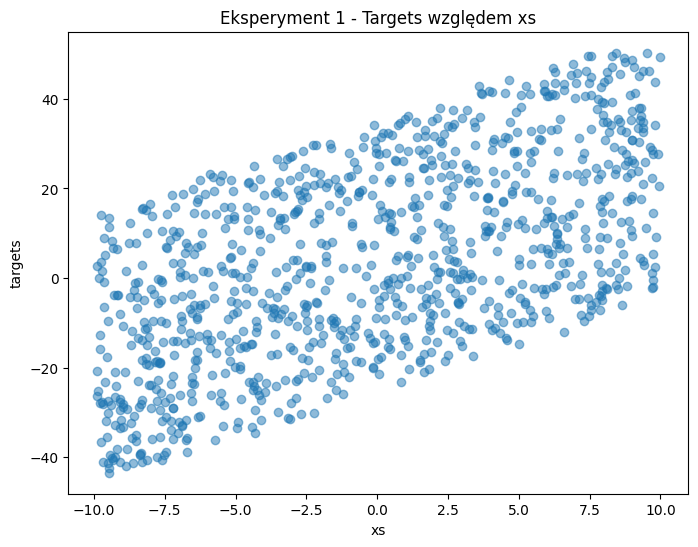

Początkowe wagi:
[[ 0.03291243]
 [-0.01179864]]
Początkowy bias:
[0.03757825]
Epoka 0, loss = 225.7878
Epoka 10, loss = 8.3831
Epoka 20, loss = 5.6521
Epoka 30, loss = 3.8288
Epoka 40, loss = 2.6116
Epoka 50, loss = 1.7989
Epoka 60, loss = 1.2564
Epoka 70, loss = 0.8942
Epoka 80, loss = 0.6524
Epoka 90, loss = 0.4910
Nauczone wagi:
[[ 2.000132]
 [-3.000231]]
Nauczony bias:
[4.34227]
Pierwsze 10 przewidywań modelu:
[[ -6.3862343]
 [ 30.489628 ]
 [ 43.30239  ]
 [  4.623324 ]
 [-33.21395  ]
 [-11.32202  ]
 [-30.166107 ]
 [ 39.274586 ]
 [ 30.150951 ]
 [-10.972712 ]]
Pierwsze 10 targetów:
[[ -6.5241094]
 [ 30.742111 ]
 [ 44.230362 ]
 [  5.1524177]
 [-33.112324 ]
 [ -9.681639 ]
 [-29.19747  ]
 [ 40.57017  ]
 [ 31.616215 ]
 [-11.038139 ]]


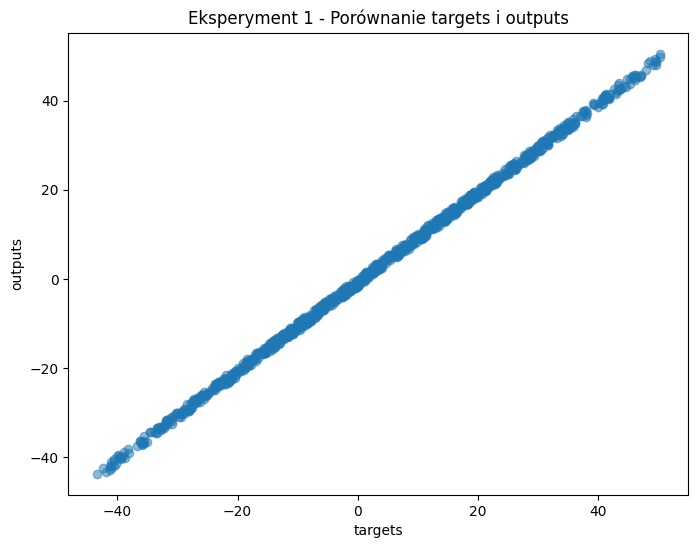

In [26]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

np.random.seed(42)
tf.random.set_seed(42)

# liczba próbek
observations = 1000000

# dane wejściowe
xs = np.random.uniform(-10, 10, size=(observations, 1))
zs = np.random.uniform(-10, 10, size=(observations, 1))
numpy_inputs = np.column_stack((xs, zs))

# szum i wartości docelowe
noise = np.random.uniform(-1, 1, size=(observations, 1))
numpy_targets = 2 * xs - 3 * zs + 5 + noise

# zapis danych
np.savez("TF_intro_1000000", inputs=numpy_inputs, targets=numpy_targets)


inputs = tf.constant(numpy_inputs, dtype=tf.float32)
targets = tf.constant(numpy_targets, dtype=tf.float32)

# wizualizacja
plt.figure(figsize=(8, 6))
plt.scatter(xs[:1000], numpy_targets[:1000], alpha=0.5)
plt.xlabel("xs")
plt.ylabel("targets")
plt.title("Eksperyment 1 - Targets względem xs")
plt.show()

# inicjalizacja wag i biasu
weights = tf.Variable(tf.random.uniform(shape=(2, 1), minval=-0.1, maxval=0.1))
bias = tf.Variable(tf.random.uniform(shape=(1,), minval=-0.1, maxval=0.1))

print("Początkowe wagi:")
print(weights.numpy())
print("Początkowy bias:")
print(bias.numpy())

# uczenie modelu
learning_rate = 0.02

for epoch in range(100):
    with tf.GradientTape() as tape:
        outputs = tf.matmul(inputs, weights) + bias
        loss = tf.reduce_mean(0.5 * tf.square(outputs - targets))

    gradients = tape.gradient(loss, [weights, bias])
    weights.assign_sub(learning_rate * gradients[0])
    bias.assign_sub(learning_rate * gradients[1])

    if epoch % 10 == 0:
        print(f"Epoka {epoch}, loss = {loss.numpy():.4f}")

# wyniki
print("Nauczone wagi:")
print(weights.numpy())
print("Nauczony bias:")
print(bias.numpy())

outputs = tf.matmul(inputs, weights) + bias

print("Pierwsze 10 przewidywań modelu:")
print(outputs.numpy()[:10])
print("Pierwsze 10 targetów:")
print(targets.numpy()[:10])

plt.figure(figsize=(8, 6))
plt.scatter(numpy_targets[:1000], outputs.numpy()[:1000], alpha=0.5)
plt.xlabel("targets")
plt.ylabel("outputs")
plt.title("Eksperyment 1 - Porównanie targets i outputs")
plt.show()

Eksperyment 2A Zmiana współczynnika uczenia eta = 0,0001.


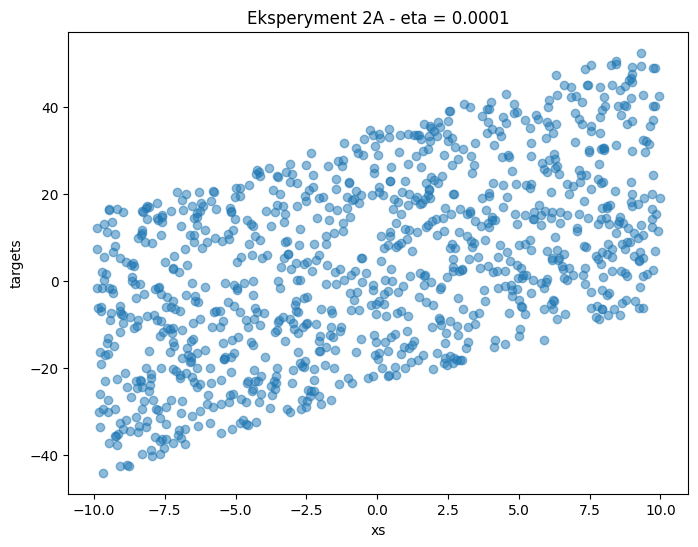

Początkowe wagi:
[[ 0.03291243]
 [-0.01179864]]
Początkowy bias:
[0.03757825]
Epoka 0, loss = 221.081085
Epoka 10, loss = 207.621094
Epoka 20, loss = 195.027130
Epoka 30, loss = 183.243317
Epoka 40, loss = 172.217453
Epoka 50, loss = 161.900681
Epoka 60, loss = 152.247330
Epoka 70, loss = 143.214569
Epoka 80, loss = 134.762466
Epoka 90, loss = 126.853554
Nauczone wagi:
[[ 0.5741161]
 [-0.8567642]]
Nauczony bias:
[0.08018494]
Pierwsze 10 przewidywań modelu:
[[ 4.0349507]
 [ 4.537447 ]
 [-3.646519 ]
 [-2.766226 ]
 [-9.122532 ]
 [-6.5905952]
 [-8.288755 ]
 [-1.6988292]
 [ 5.53073  ]
 [ 2.6505475]]
Pierwsze 10 targetów:
[[ 18.397041  ]
 [ 20.008472  ]
 [ -7.2844834 ]
 [ -5.4880614 ]
 [-27.609024  ]
 [-17.768425  ]
 [-24.31377   ]
 [ -0.75127214]
 [ 23.195251  ]
 [ 13.932548  ]]


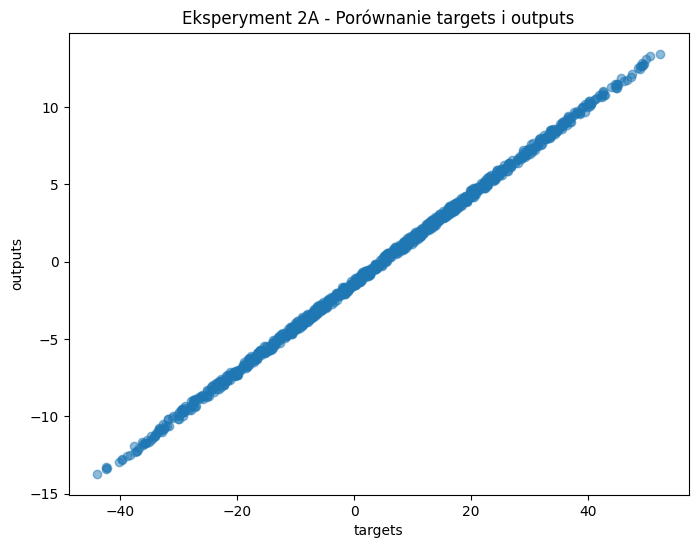

In [28]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

np.random.seed(42)
tf.random.set_seed(42)

# liczba próbek
observations = 1000

# dane wejściowe
xs = np.random.uniform(-10, 10, size=(observations, 1))
zs = np.random.uniform(-10, 10, size=(observations, 1))


numpy_inputs = np.column_stack((xs, zs))

# szum i wartości docelowe
noise = np.random.uniform(-1, 1, size=(observations, 1))
numpy_targets = 2 * xs - 3 * zs + 5 + noise


inputs = tf.constant(numpy_inputs, dtype=tf.float32)
targets = tf.constant(numpy_targets, dtype=tf.float32)

# wizualizacja
plt.figure(figsize=(8, 6))
plt.scatter(xs, numpy_targets, alpha=0.5)
plt.xlabel("xs")
plt.ylabel("targets")
plt.title("Eksperyment 2A - eta = 0.0001")
plt.show()

# inicjalizacja wag i biasu
weights = tf.Variable(tf.random.uniform(shape=(2, 1), minval=-0.1, maxval=0.1))
bias = tf.Variable(tf.random.uniform(shape=(1,), minval=-0.1, maxval=0.1))

print("Początkowe wagi:")
print(weights.numpy())
print("Początkowy bias:")
print(bias.numpy())

# uczenie modelu
learning_rate = 0.0001

for epoch in range(100):
    with tf.GradientTape() as tape:
        outputs = tf.matmul(inputs, weights) + bias
        loss = tf.reduce_mean(0.5 * tf.square(outputs - targets))

    gradients = tape.gradient(loss, [weights, bias])
    weights.assign_sub(learning_rate * gradients[0])
    bias.assign_sub(learning_rate * gradients[1])

    if epoch % 10 == 0:
        print(f"Epoka {epoch}, loss = {loss.numpy():.6f}")

# wyniki
print("Nauczone wagi:")
print(weights.numpy())
print("Nauczony bias:")
print(bias.numpy())

outputs = tf.matmul(inputs, weights) + bias

print("Pierwsze 10 przewidywań modelu:")
print(outputs.numpy()[:10])
print("Pierwsze 10 targetów:")
print(targets.numpy()[:10])

plt.figure(figsize=(8, 6))
plt.scatter(numpy_targets, outputs.numpy(), alpha=0.5)
plt.xlabel("targets")
plt.ylabel("outputs")
plt.title("Eksperyment 2A - Porównanie targets i outputs")
plt.show()

Eksperyment 2B Zmiana współczynnika uczenia na eta = 0,001


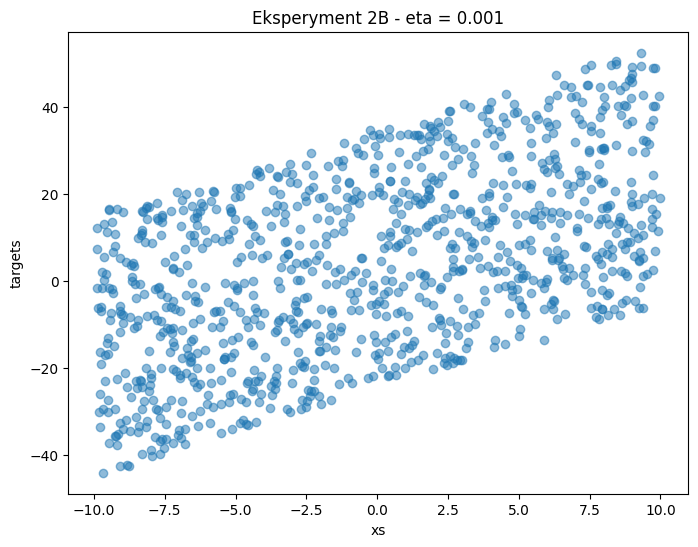

Początkowe wagi:
[[ 0.03291243]
 [-0.01179864]]
Początkowy bias:
[0.03757825]
Epoka 0, loss = 221.081085
Epoka 10, loss = 118.365952
Epoka 20, loss = 66.024651
Epoka 30, loss = 39.296314
Epoka 40, loss = 25.593079
Epoka 50, loss = 18.515079
Epoka 60, loss = 14.808264
Epoka 70, loss = 12.817981
Epoka 80, loss = 11.702751
Epoka 90, loss = 11.034623
Nauczone wagi:
[[ 1.904579 ]
 [-2.8789654]]
Nauczony bias:
[0.48816255]
Pierwsze 10 przewidywań modelu:
[[ 13.8390255]
 [ 15.243957 ]
 [-12.148784 ]
 [ -9.125128 ]
 [-30.266209 ]
 [-21.758186 ]
 [-27.416283 ]
 [ -5.670052 ]
 [ 18.753736 ]
 [  9.02288  ]]
Pierwsze 10 targetów:
[[ 18.397041  ]
 [ 20.008472  ]
 [ -7.2844834 ]
 [ -5.4880614 ]
 [-27.609024  ]
 [-17.768425  ]
 [-24.31377   ]
 [ -0.75127214]
 [ 23.195251  ]
 [ 13.932548  ]]


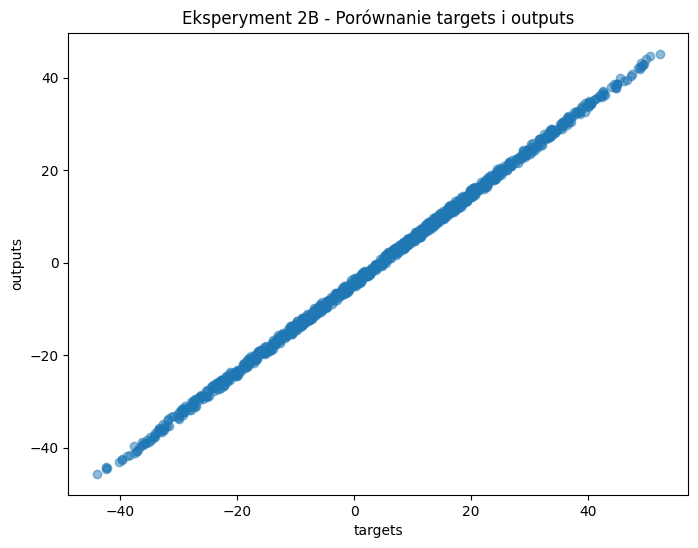

In [30]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

np.random.seed(42)
tf.random.set_seed(42)

# liczba próbek
observations = 1000

# dane wejściowe
xs = np.random.uniform(-10, 10, size=(observations, 1))
zs = np.random.uniform(-10, 10, size=(observations, 1))

numpy_inputs = np.column_stack((xs, zs))

# szum i wartości docelowe
noise = np.random.uniform(-1, 1, size=(observations, 1))
numpy_targets = 2 * xs - 3 * zs + 5 + noise


inputs = tf.constant(numpy_inputs, dtype=tf.float32)
targets = tf.constant(numpy_targets, dtype=tf.float32)

# wizualizacja
plt.figure(figsize=(8, 6))
plt.scatter(xs, numpy_targets, alpha=0.5)
plt.xlabel("xs")
plt.ylabel("targets")
plt.title("Eksperyment 2B - eta = 0.001")
plt.show()

# inicjalizacja wag i biasu
weights = tf.Variable(tf.random.uniform(shape=(2, 1), minval=-0.1, maxval=0.1))
bias = tf.Variable(tf.random.uniform(shape=(1,), minval=-0.1, maxval=0.1))

print("Początkowe wagi:")
print(weights.numpy())
print("Początkowy bias:")
print(bias.numpy())

# uczenie modelu
learning_rate = 0.001

for epoch in range(100):
    with tf.GradientTape() as tape:
        outputs = tf.matmul(inputs, weights) + bias
        loss = tf.reduce_mean(0.5 * tf.square(outputs - targets))

    gradients = tape.gradient(loss, [weights, bias])
    weights.assign_sub(learning_rate * gradients[0])
    bias.assign_sub(learning_rate * gradients[1])

    if epoch % 10 == 0:
        print(f"Epoka {epoch}, loss = {loss.numpy():.6f}")

# wyniki
print("Nauczone wagi:")
print(weights.numpy())
print("Nauczony bias:")
print(bias.numpy())

outputs = tf.matmul(inputs, weights) + bias

print("Pierwsze 10 przewidywań modelu:")
print(outputs.numpy()[:10])
print("Pierwsze 10 targetów:")
print(targets.numpy()[:10])

plt.figure(figsize=(8, 6))
plt.scatter(numpy_targets, outputs.numpy(), alpha=0.5)
plt.xlabel("targets")
plt.ylabel("outputs")
plt.title("Eksperyment 2B - Porównanie targets i outputs")
plt.show()

Eksperyment 2C Zmiana współczynnika uczenia na eta = 0,1

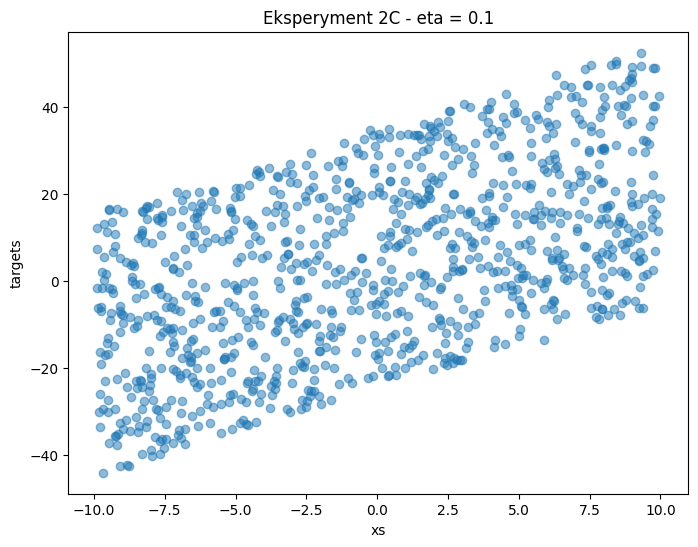

Początkowe wagi:
[[ 0.03291243]
 [-0.01179864]]
Początkowy bias:
[0.03757825]
Epoka 0, loss = 221.081085
Epoka 10, loss = 4859509760.000000
Epoka 20, loss = 168164445132947456.000000
Epoka 30, loss = 10463962845593432034902016.000000
Epoka 40, loss = 915845759080136599375556594630656.000000
Epoka 50, loss = inf
Epoka 60, loss = inf
Epoka 70, loss = inf
Epoka 80, loss = inf
Epoka 90, loss = inf
Nauczone wagi:
[[nan]
 [nan]]
Nauczony bias:
[nan]
Pierwsze 10 przewidywań modelu:
[[nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]]
Pierwsze 10 targetów:
[[ 18.397041  ]
 [ 20.008472  ]
 [ -7.2844834 ]
 [ -5.4880614 ]
 [-27.609024  ]
 [-17.768425  ]
 [-24.31377   ]
 [ -0.75127214]
 [ 23.195251  ]
 [ 13.932548  ]]


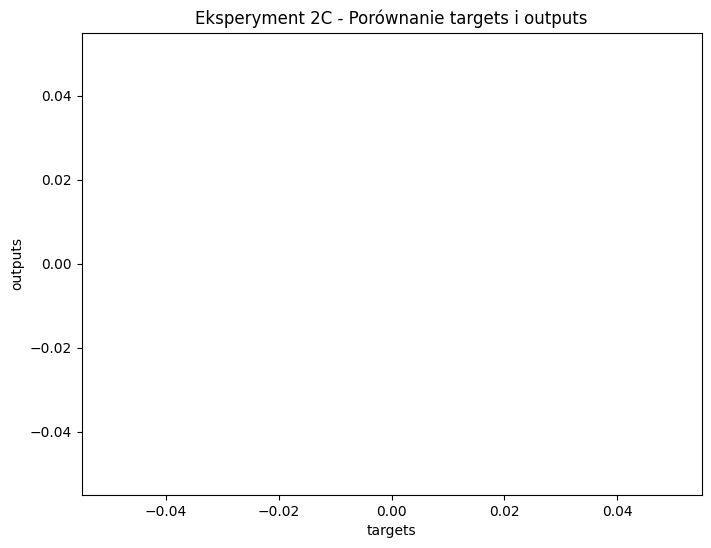

In [32]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

np.random.seed(42)
tf.random.set_seed(42)

# liczba próbek
observations = 1000

# dane wejściowe
xs = np.random.uniform(-10, 10, size=(observations, 1))
zs = np.random.uniform(-10, 10, size=(observations, 1))
numpy_inputs = np.column_stack((xs, zs))

# szum i wartości docelowe
noise = np.random.uniform(-1, 1, size=(observations, 1))
numpy_targets = 2 * xs - 3 * zs + 5 + noise


inputs = tf.constant(numpy_inputs, dtype=tf.float32)
targets = tf.constant(numpy_targets, dtype=tf.float32)

# wizualizacja
plt.figure(figsize=(8, 6))
plt.scatter(xs, numpy_targets, alpha=0.5)
plt.xlabel("xs")
plt.ylabel("targets")
plt.title("Eksperyment 2C - eta = 0.1")
plt.show()

# inicjalizacja wag i biasu
weights = tf.Variable(tf.random.uniform(shape=(2, 1), minval=-0.1, maxval=0.1))
bias = tf.Variable(tf.random.uniform(shape=(1,), minval=-0.1, maxval=0.1))

print("Początkowe wagi:")
print(weights.numpy())
print("Początkowy bias:")
print(bias.numpy())

# uczenie modelu
learning_rate = 0.1

for epoch in range(100):
    with tf.GradientTape() as tape:
        outputs = tf.matmul(inputs, weights) + bias
        loss = tf.reduce_mean(0.5 * tf.square(outputs - targets))

    gradients = tape.gradient(loss, [weights, bias])
    weights.assign_sub(learning_rate * gradients[0])
    bias.assign_sub(learning_rate * gradients[1])

    if epoch % 10 == 0:
        print(f"Epoka {epoch}, loss = {loss.numpy():.6f}")

# wyniki
print("Nauczone wagi:")
print(weights.numpy())
print("Nauczony bias:")
print(bias.numpy())

outputs = tf.matmul(inputs, weights) + bias

print("Pierwsze 10 przewidywań modelu:")
print(outputs.numpy()[:10])
print("Pierwsze 10 targetów:")
print(targets.numpy()[:10])

plt.figure(figsize=(8, 6))
plt.scatter(numpy_targets, outputs.numpy(), alpha=0.5)
plt.xlabel("targets")
plt.ylabel("outputs")
plt.title("Eksperyment 2C - Porównanie targets i outputs")
plt.show()

Eksperyment 2D Zmiana współczynnika uczenia na eta = 1.

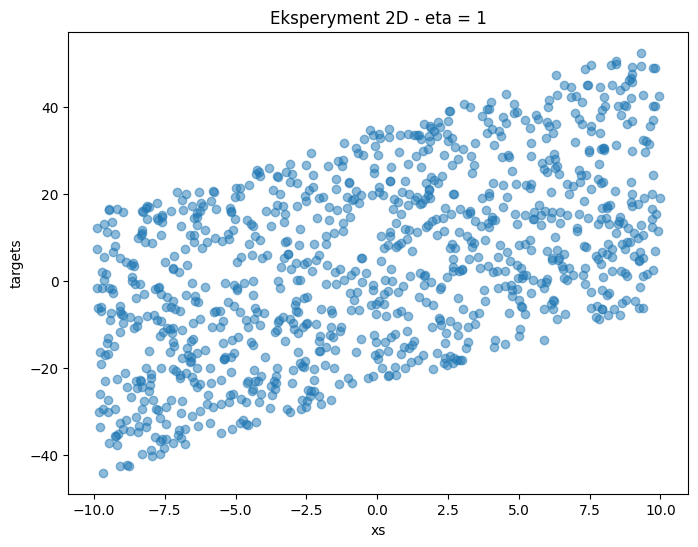

Początkowe wagi:
[[ 0.03291243]
 [-0.01179864]]
Początkowy bias:
[0.03757825]
Epoka 0, loss = 221.081085
Epoka 10, loss = 321931123576628485170149283856384.000000
Epoka 20, loss = inf
Epoka 30, loss = nan
Epoka 40, loss = nan
Epoka 50, loss = nan
Epoka 60, loss = nan
Epoka 70, loss = nan
Epoka 80, loss = nan
Epoka 90, loss = nan
Nauczone wagi:
[[nan]
 [nan]]
Nauczony bias:
[nan]
Pierwsze 10 przewidywań modelu:
[[nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]]
Pierwsze 10 targetów:
[[ 18.397041  ]
 [ 20.008472  ]
 [ -7.2844834 ]
 [ -5.4880614 ]
 [-27.609024  ]
 [-17.768425  ]
 [-24.31377   ]
 [ -0.75127214]
 [ 23.195251  ]
 [ 13.932548  ]]


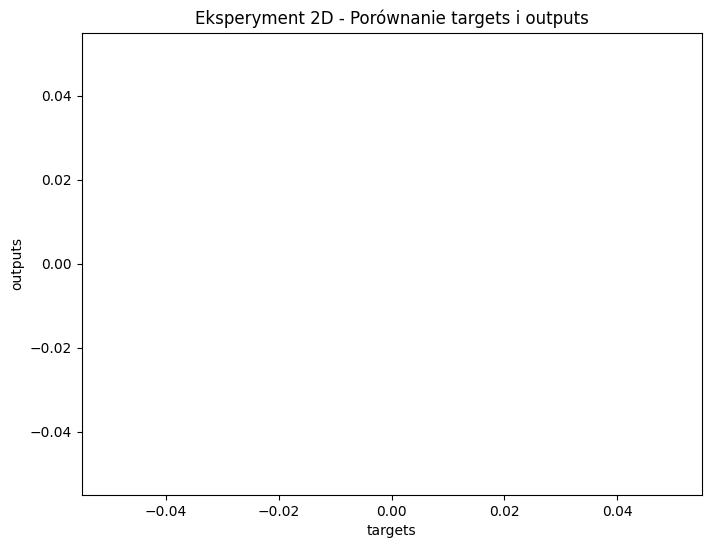

In [34]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

np.random.seed(42)
tf.random.set_seed(42)

# liczba próbek
observations = 1000

# dane wejściowe
xs = np.random.uniform(-10, 10, size=(observations, 1))
zs = np.random.uniform(-10, 10, size=(observations, 1))

numpy_inputs = np.column_stack((xs, zs))

# szum i wartości docelowe
noise = np.random.uniform(-1, 1, size=(observations, 1))

numpy_targets = 2 * xs - 3 * zs + 5 + noise


inputs = tf.constant(numpy_inputs, dtype=tf.float32)
targets = tf.constant(numpy_targets, dtype=tf.float32)

# wizualizacja
plt.figure(figsize=(8, 6))
plt.scatter(xs, numpy_targets, alpha=0.5)
plt.xlabel("xs")
plt.ylabel("targets")
plt.title("Eksperyment 2D - eta = 1")
plt.show()

# inicjalizacja wag i biasu
weights = tf.Variable(tf.random.uniform(shape=(2, 1), minval=-0.1, maxval=0.1))
bias = tf.Variable(tf.random.uniform(shape=(1,), minval=-0.1, maxval=0.1))

print("Początkowe wagi:")
print(weights.numpy())
print("Początkowy bias:")
print(bias.numpy())

# uczenie modelu
learning_rate = 1.0

for epoch in range(100):
    with tf.GradientTape() as tape:
        outputs = tf.matmul(inputs, weights) + bias
        loss = tf.reduce_mean(0.5 * tf.square(outputs - targets))

    gradients = tape.gradient(loss, [weights, bias])
    weights.assign_sub(learning_rate * gradients[0])
    bias.assign_sub(learning_rate * gradients[1])

    if epoch % 10 == 0:
        print(f"Epoka {epoch}, loss = {loss.numpy():.6f}")

# wyniki
print("Nauczone wagi:")
print(weights.numpy())
print("Nauczony bias:")
print(bias.numpy())

outputs = tf.matmul(inputs, weights) + bias

print("Pierwsze 10 przewidywań modelu:")
print(outputs.numpy()[:10])
print("Pierwsze 10 targetów:")
print(targets.numpy()[:10])

plt.figure(figsize=(8, 6))
plt.scatter(numpy_targets, outputs.numpy(), alpha=0.5)
plt.xlabel("targets")
plt.ylabel("outputs")
plt.title("Eksperyment 2D - Porównanie targets i outputs")
plt.show()

Eksperyment 3. Zmiana targets na 13 * xs + 7 * zs - 12

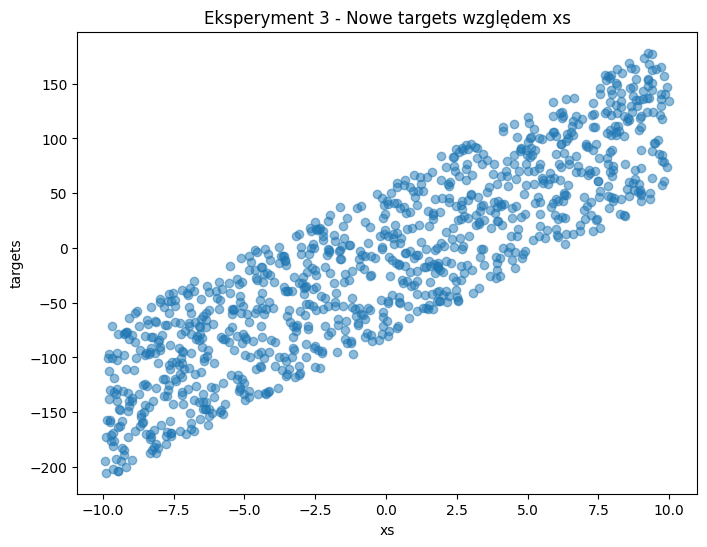

Początkowe wagi:
[[ 0.03291243]
 [-0.01179864]]
Początkowy bias:
[0.03757825]
Epoka 0, loss = 3890.339111
Epoka 10, loss = 48.069977
Epoka 20, loss = 32.171322
Epoka 30, loss = 21.549503
Epoka 40, loss = 14.453116
Epoka 50, loss = 9.712035
Epoka 60, loss = 6.544547
Epoka 70, loss = 4.428365
Epoka 80, loss = 3.014551
Epoka 90, loss = 2.069984
Nauczone wagi:
[[13.010952 ]
 [ 6.9956346]]
Nauczony bias:
[-10.400006]
Pierwsze 10 przewidywań modelu:
[[-87.10096 ]
 [112.74691 ]
 [102.149086]
 [ 47.76402 ]
 [-57.01871 ]
 [-77.70098 ]
 [-98.49313 ]
 [133.7429  ]
 [-19.11258 ]
 [ 42.26486 ]]
Pierwsze 10 targetów:
[[ -89.17755 ]
 [ 110.54581 ]
 [ 101.34335 ]
 [  45.66178 ]
 [ -58.972694]
 [ -78.692955]
 [-100.08006 ]
 [ 132.6466  ]
 [ -21.625843]
 [  40.593506]]


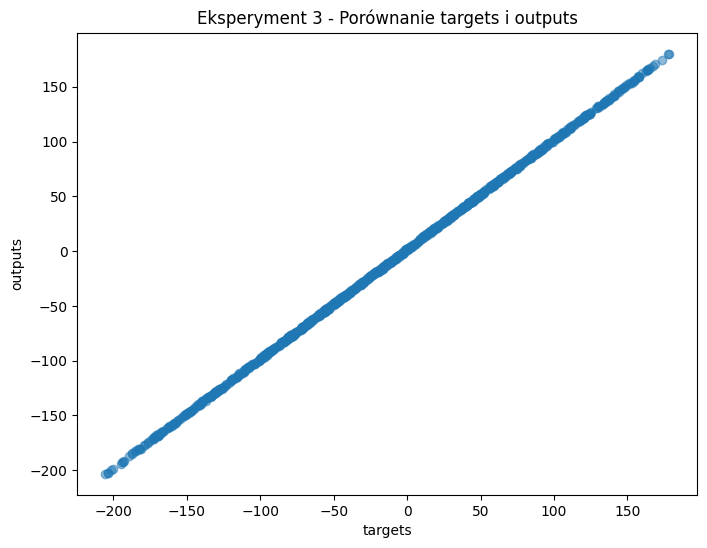

In [36]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

np.random.seed(42)
tf.random.set_seed(42)

# liczba próbek
observations = 1000

# dane wejściowe
xs = np.random.uniform(-10, 10, size=(observations, 1))
zs = np.random.uniform(-10, 10, size=(observations, 1))
numpy_inputs = np.column_stack((xs, zs))

# szum i nowe wartości docelowe
noise = np.random.uniform(-1, 1, size=(observations, 1))
numpy_targets = 13 * xs + 7 * zs - 12 + noise

# zapis danych
np.savez("TF_intro_new_targets", inputs=numpy_inputs, targets=numpy_targets)


inputs = tf.constant(numpy_inputs, dtype=tf.float32)
targets = tf.constant(numpy_targets, dtype=tf.float32)

# wizualizacja
plt.figure(figsize=(8, 6))
plt.scatter(xs, numpy_targets, alpha=0.5)
plt.xlabel("xs")
plt.ylabel("targets")
plt.title("Eksperyment 3 - Nowe targets względem xs")
plt.show()

# inicjalizacja wag i biasu
weights = tf.Variable(tf.random.uniform(shape=(2, 1), minval=-0.1, maxval=0.1))
bias = tf.Variable(tf.random.uniform(shape=(1,), minval=-0.1, maxval=0.1))

print("Początkowe wagi:")
print(weights.numpy())
print("Początkowy bias:")
print(bias.numpy())

# uczenie modelu
learning_rate = 0.02

for epoch in range(100):
    with tf.GradientTape() as tape:
        outputs = tf.matmul(inputs, weights) + bias
        loss = tf.reduce_mean(0.5 * tf.square(outputs - targets))

    gradients = tape.gradient(loss, [weights, bias])
    weights.assign_sub(learning_rate * gradients[0])
    bias.assign_sub(learning_rate * gradients[1])

    if epoch % 10 == 0:
        print(f"Epoka {epoch}, loss = {loss.numpy():.6f}")

# wyniki
print("Nauczone wagi:")
print(weights.numpy())
print("Nauczony bias:")
print(bias.numpy())

outputs = tf.matmul(inputs, weights) + bias

print("Pierwsze 10 przewidywań modelu:")
print(outputs.numpy()[:10])
print("Pierwsze 10 targetów:")
print(targets.numpy()[:10])

plt.figure(figsize=(8, 6))
plt.scatter(numpy_targets, outputs.numpy(), alpha=0.5)
plt.xlabel("targets")
plt.ylabel("outputs")
plt.title("Eksperyment 3 - Porównanie targets i outputs")
plt.show()

Eksperyment własny. Zmiana ilości próbek na 500000, zmiana współczynnika na 0,5 i targets.

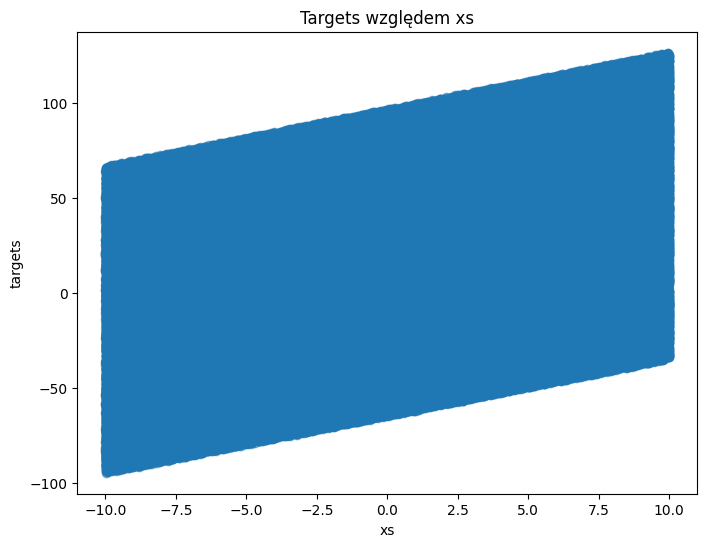

Początkowe wagi:
[[ 0.03291243]
 [-0.01179864]]
Początkowy bias:
[0.03757825]
Epoka 0, loss = 1337.3145
Epoka 10, loss = 963225518729499224529960960.0000
Epoka 20, loss = inf
Epoka 30, loss = inf
Epoka 40, loss = nan
Epoka 50, loss = nan
Epoka 60, loss = nan
Epoka 70, loss = nan
Epoka 80, loss = nan
Epoka 90, loss = nan
Nauczone wagi:
[[nan]
 [nan]]
Nauczony bias:
[nan]
Pierwsze 10 przewidywań modelu:
[[nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]]
Pierwsze 10 targetów:
tf.Tensor(
[[ 40.8051   ]
 [ 41.252697 ]
 [  5.899753 ]
 [-56.706364 ]
 [-35.1059   ]
 [ -1.1619374]
 [  5.506689 ]
 [ 68.4561   ]
 [ 73.38926  ]
 [ 61.50233  ]], shape=(10, 1), dtype=float32)


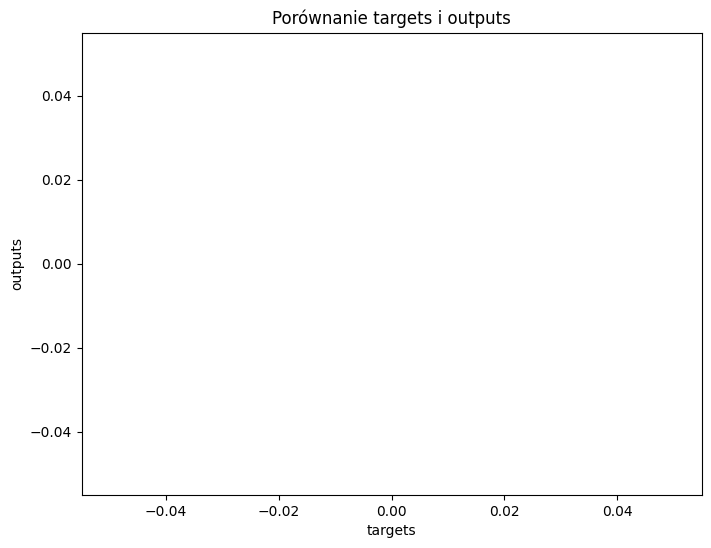

In [37]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

np.random.seed(42)
tf.random.set_seed(42)

observations = 500000

xs = np.random.uniform(-10, 10, size=(observations, 1))
zs = np.random.uniform(-10, 10, size=(observations, 1))

inputs = np.column_stack((xs, zs))

noise = np.random.uniform(-1, 1, size=(observations, 1))

targets = 3 * xs - 8 * zs + 16 + noise

np.savez("TF_intro", inputs=inputs, targets=targets)


numpy_targets = targets
numpy_inputs = inputs
inputs = tf.constant(inputs, dtype=tf.float32)
targets = tf.constant(targets, dtype=tf.float32)

plt.figure(figsize=(8, 6))
plt.scatter(xs, numpy_targets, alpha=0.5)
plt.xlabel("xs")
plt.ylabel("targets")
plt.title("Targets względem xs")
plt.show()

weights = tf.Variable(tf.random.uniform(shape=(2, 1), minval=-0.1, maxval=0.1))
bias = tf.Variable(tf.random.uniform(shape=(1,), minval=-0.1, maxval=0.1))

print("Początkowe wagi:")
print(weights.numpy())

print("Początkowy bias:")
print(bias.numpy())

learning_rate = 0.5

for epoch in range(100):
    with tf.GradientTape() as tape:
        outputs = tf.matmul(inputs, weights) + bias
        loss = tf.reduce_mean(0.5 * tf.square(outputs - targets))

    gradients = tape.gradient(loss, [weights, bias])
    weights.assign_sub(learning_rate * gradients[0])
    bias.assign_sub(learning_rate * gradients[1])

    if epoch % 10 == 0:
        print(f"Epoka {epoch}, loss = {loss.numpy():.4f}")


print("Nauczone wagi:")
print(weights.numpy())

print("Nauczony bias:")
print(bias.numpy())


outputs = tf.matmul(inputs, weights) + bias

print("Pierwsze 10 przewidywań modelu:")
print(outputs.numpy()[:10])

print("Pierwsze 10 targetów:")
print(targets[:10])


plt.figure(figsize=(8, 6))
plt.scatter(targets, outputs.numpy(), alpha=0.5)
plt.xlabel("targets")
plt.ylabel("outputs")
plt.title("Porównanie targets i outputs")
plt.show()